# 🧠 Sentence Memorability Experiment — Data Visualization

**Continuous Recognition Experiment** analysing how sentence memorability is affected by structure (Active / Passive voice) and constituent word memorability (High / Low for Subject and Object nouns).

### Sentence Types
| Log Code | Label | Subject | Object |
|----------|-------|---------|--------|
| `HH`  | HH | High | High |
| `HVL` | HL | High | Low  |
| `LVH` | LH | Low  | High |
| `LVL` | LL | Low  | Low  |

### Voice
- **Active** (`_A`) vs **Passive** (`_P`)

### Exclusion Criterion (per block)
> `#Correct_validation_IRs > (#Wrong_IRs / 2) + #Missed_validation_IRs`

## 1. Setup — Import Libraries & Configuration

In [68]:
import os
import glob
from collections import defaultdict
from itertools import combinations
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline

# ── Visual style ──
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "sans-serif",
})

# ── Constants ──
LOG_DIR     = "NewLogsAnonymized"
PLOT_DIR    = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

TYPE_MAP    = {"HH": "HH", "HVL": "HL", "LVH": "LH", "LVL": "LL"}
TYPE_ORDER  = ["HH", "HL", "LH", "LL"]
VOICE_ORDER = ["Active", "Passive"]
COND_ORDER  = [f"{t}_{v}" for t in TYPE_ORDER for v in VOICE_ORDER]

TYPE_PALETTE  = {"HH": "#2196F3", "HL": "#FF9800", "LH": "#4CAF50", "LL": "#E64A19"}
VOICE_PALETTE = {"Active": "#1565C0", "Passive": "#C62828"}
COND_PALETTE  = {
    "HH_Active": "#1976D2", "HH_Passive": "#64B5F6",
    "HL_Active": "#E65100", "HL_Passive": "#FFB74D",
    "LH_Active": "#2E7D32", "LH_Passive": "#81C784",
    "LL_Active": "#BF360C", "LL_Passive": "#FF8A65",
}

def mean_ci(series, confidence=0.95):
    """Return (mean, 95% CI half-width)."""
    n = len(series)
    m = series.mean()
    if n < 2:
        return m, 0
    se = series.sem()
    ci = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return m, ci

print("✅ Libraries loaded and configuration set.")

✅ Libraries loaded and configuration set.


## 2. Load & Parse Log Files

In [69]:
# ── Load all log files into an IMMUTABLE raw dataframe ──
frames = []
for fp in sorted(glob.glob(os.path.join(LOG_DIR, "*.log"))):
    frames.append(pd.read_csv(fp, na_values=["N/A", ""]))

df_raw = pd.concat(frames, ignore_index=True)      # ← original, NEVER modified
df_raw.columns = df_raw.columns.str.strip()

print(f"Rows loaded       : {len(df_raw):,}")
print(f"Participants found : {df_raw['participant_ID'].nunique()}")
print(f"\n✅ Original dataset stored in  df_raw  — this will NOT be modified.")
print(f"   All transformations happen on a working copy (df).")
df_raw.head(5)

Rows loaded       : 81,329
Participants found : 114

✅ Original dataset stored in  df_raw  — this will NOT be modified.
   All transformations happen on a working copy (df).


,participant_ID,Timestamp,Event,Stimulus,isTarget,isValidation,isRepeat,Button,Accuracy IR,Accuracy WR,Reaction_time_IR,Reaction_time_WR,CR_IR,CR_WR
0,232,1770218920752,Practice Sentence shown,HH_112_A,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,232,1770218923564,Practice IR pressed,HH_112_A,True,NaN,NaN,Spacebar,0.0,NaN,2812.0,NaN,NaN,NaN
2,232,1770218924911,Practice Sentence shown,HL_16_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,232,1770218930413,Practice Sentence shown,HH_116_A,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,232,1770218935915,Practice Sentence shown,HL_62_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Exclusion Criteria — Block Validation

> **Rule:** A block is **excluded** if it fails the validation test:
>
> $$\text{Correct Validation IRs} > \frac{\text{Wrong IRs}}{2} + \text{Missed Validation IRs}$$
>
> Blocks that **do not** satisfy this inequality are dropped from all downstream memorability calculations.

⚠️ The original dataset (`df_raw`) is **never modified**. All filtering is applied dynamically on a working copy.

In [70]:
# ══════════════════════════════════════════════════════════════════════
# STEP A — Create a WORKING COPY and parse (original df_raw untouched)
# ══════════════════════════════════════════════════════════════════════
df = df_raw.copy()

# Boolean columns
for c in ("isTarget", "isValidation", "isRepeat"):
    df[c] = df[c].map({"true": True, True: True}).fillna(False)

# Numeric columns
for c in ("Accuracy IR", "Accuracy WR", "Reaction_time_IR", "Reaction_time_WR"):
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Parse stimulus codes
def parse_stimulus(stim):
    if pd.isna(stim):
        return None, None, None
    parts = stim.split("_")
    if len(parts) < 3:
        return None, None, None
    raw_type, sid, vcode = parts[0], parts[1], parts[2]
    stype = TYPE_MAP.get(raw_type)
    voice = {"A": "Active", "P": "Passive"}.get(vcode)
    return stype, sid, voice

parsed = df["Stimulus"].apply(parse_stimulus)
df["sent_type"] = [p[0] for p in parsed]
df["sent_id"]   = [p[1] for p in parsed]
df["voice"]     = [p[2] for p in parsed]

# ══════════════════════════════════════════════════════════════════════
# STEP B — Assign blocks  (practice = -1, experimental = 1, 2, 3)
# ══════════════════════════════════════════════════════════════════════
block_col = []
for _, grp in df.groupby("participant_ID", sort=False):
    blk = -1
    practice_done = False
    for ev in grp["Event"].values:
        if isinstance(ev, str) and ev.startswith("Practice"):
            block_col.append(-1)
            continue
        if not practice_done:
            practice_done = True
            blk = 1
        if isinstance(ev, str) and ev == "Rest Phase started":
            block_col.append(blk)
            blk += 1
            continue
        block_col.append(blk)

df["block"] = block_col
df_main = df[df["block"] > 0].copy()   # drop practice rows

# ══════════════════════════════════════════════════════════════════════
# STEP C — Block-level validation (exclusion formula)
#   Correct_validation_IRs > (Wrong_IRs / 2) + Missed_validation_IRs
# ══════════════════════════════════════════════════════════════════════
def validate_block(bdf):
    """Apply the exclusion formula to one participant-block."""
    correct_val_ir = (bdf["Event"] == "Validation IR pressed").sum()
    wrong_ir       = (bdf["Event"] == "Validation Wrong IR pressed").sum()

    # Missed = validation repeats that were shown but never correctly detected
    val_repeats_shown = (
        (bdf["Event"] == "Sentence shown") &
        (bdf["isValidation"] == True) &
        (bdf["isRepeat"] == True)
    ).sum()
    missed_val_ir = max(0, val_repeats_shown - correct_val_ir)

    passes = correct_val_ir > (wrong_ir / 2) + missed_val_ir
    return passes, correct_val_ir, wrong_ir, missed_val_ir

validity_records = []
for (pid, blk), bdf in df_main.groupby(["participant_ID", "block"]):
    ok, c, w, m = validate_block(bdf)
    validity_records.append({
        "participant_ID": pid, "block": blk,
        "valid": ok,
        "correct_val_IRs": c, "wrong_IRs": w, "missed_val_IRs": m,
        "formula_LHS": c,
        "formula_RHS": (w / 2) + m,
    })

val_df = pd.DataFrame(validity_records)

# Tag each row in df_main with its block's validity (without altering df_raw)
df_main = df_main.merge(val_df[["participant_ID", "block", "valid"]],
                        on=["participant_ID", "block"], how="left")

# ══════════════════════════════════════════════════════════════════════
# STEP D — Filter to valid blocks only
# ══════════════════════════════════════════════════════════════════════
df_valid = df_main[df_main["valid"] == True].copy()

total_blocks    = len(val_df)
excluded_blocks = (~val_df["valid"]).sum()
valid_blocks    = total_blocks - excluded_blocks
parts_with_any  = val_df.groupby("participant_ID")["valid"].any()
excluded_parts  = (~parts_with_any).sum()
total_parts     = df["participant_ID"].nunique()

print("=" * 55)
print("  EXCLUSION CRITERIA RESULTS")
print("=" * 55)
print(f"  Original df_raw shape      : {df_raw.shape}  (UNCHANGED)")
print(f"  Working copy rows (no prac): {len(df_main):,}")
print(f"  ─────────────────────────────────────────────")
print(f"  Total participant-blocks   : {total_blocks}")
print(f"  ✅ Valid blocks             : {valid_blocks}  ({100*valid_blocks/total_blocks:.1f}%)")
print(f"  ❌ Excluded blocks          : {excluded_blocks}  ({100*excluded_blocks/total_blocks:.1f}%)")
print(f"  ─────────────────────────────────────────────")
print(f"  Total participants         : {total_parts}")
print(f"  Fully excluded (all blocks): {excluded_parts}")
print(f"  Remaining valid rows       : {len(df_valid):,}")
print("=" * 55)

  EXCLUSION CRITERIA RESULTS
  Original df_raw shape      : (81329, 14)  (UNCHANGED)
  Working copy rows (no prac): 76,060
  ─────────────────────────────────────────────
  Total participant-blocks   : 342
  ✅ Valid blocks             : 329  (96.2%)
  ❌ Excluded blocks          : 13  (3.8%)
  ─────────────────────────────────────────────
  Total participants         : 114
  Fully excluded (all blocks): 2
  Remaining valid rows       : 72,844


### 3a. Excluded Blocks — Detail Table
Show every block that **failed** the validation check, with the formula components.

In [71]:
# Show the excluded blocks with formula components
excluded_df = val_df[~val_df["valid"]].copy()
excluded_df["formula"] = (
    excluded_df.apply(
        lambda r: f"{r['correct_val_IRs']}  >  ({r['wrong_IRs']}/2) + {r['missed_val_IRs']}  =  {r['formula_RHS']:.1f}  →  FAIL",
        axis=1
    )
)
print(f"❌  {len(excluded_df)} block(s) excluded:\n")
display(excluded_df[["participant_ID", "block",
                     "correct_val_IRs", "wrong_IRs", "missed_val_IRs",
                     "formula_LHS", "formula_RHS", "formula"]]
        .rename(columns={"correct_val_IRs": "Correct Val IRs",
                         "wrong_IRs": "Wrong IRs",
                         "missed_val_IRs": "Missed Val IRs",
                         "formula_LHS": "LHS",
                         "formula_RHS": "RHS"})
        .reset_index(drop=True)
        .to_string(index=False))

# Confirm original is untouched
print(f"\n✅ Verification: df_raw shape is still {df_raw.shape} — original data unchanged.")

❌  13 block(s) excluded:



' participant_ID  block  Correct Val IRs  Wrong IRs  Missed Val IRs  LHS  RHS                             formula\n            245      1                7         10               3    7  8.0   7  >  (10/2) + 3  =  8.0  →  FAIL\n            258      1                7          8               3    7  7.0    7  >  (8/2) + 3  =  7.0  →  FAIL\n            271      1               10         25               0   10 12.5 10  >  (25/2) + 0  =  12.5  →  FAIL\n            271      2               10         21               0   10 10.5 10  >  (21/2) + 0  =  10.5  →  FAIL\n            271      3               10         27               0   10 13.5 10  >  (27/2) + 0  =  13.5  →  FAIL\n            294      1                9         18               1    9 10.0  9  >  (18/2) + 1  =  10.0  →  FAIL\n            297      2               10         20               0   10 10.0 10  >  (20/2) + 0  =  10.0  →  FAIL\n            299      1                7          9               3    7  7.5    7  >  (


✅ Verification: df_raw shape is still (81329, 14) — original data unchanged.


## 4. Compute Memorability Scores

- **Hit Rate (HR)** = Proportion of repeated targets correctly recognised (IR press)
- **False-Alarm Rate (FAR)** = Proportion of non-target filler sentences incorrectly flagged
- **Corrected Memorability** = HR − FAR

In [72]:
# ── 4a. Overall per participant-block metrics ──
pb_metrics = []
for (pid, blk), g in df_valid.groupby(["participant_ID", "block"]):
    repeats_shown = g[(g["Event"] == "Sentence shown") &
                      (g["isTarget"]) & (g["isRepeat"]) &
                      (g["sent_type"].notna())]
    hits = g[(g["Event"] == "IR pressed") &
             (g["isTarget"]) & (g["isRepeat"]) &
             (g["sent_type"].notna()) & (g["Accuracy IR"] == 1)]
    fa = g[(g["Event"] == "Validation Wrong IR pressed") &
           (g["sent_type"].notna())]
    first_shown = g[(g["Event"] == "Sentence shown") &
                    (g["isTarget"]) & (~g["isRepeat"]) &
                    (g["sent_type"].notna())]

    nr, nh, nf, nfirst = len(repeats_shown), len(hits), len(fa), len(first_shown)
    hr  = nh / nr if nr else 0
    far = nf / nfirst if nfirst else 0
    pb_metrics.append(dict(participant_ID=pid, block=blk,
                           hit_rate=hr, fa_rate=far, corrected=hr - far,
                           n_repeats=nr, n_hits=nh, n_fa=nf, n_first=nfirst))

pb_df = pd.DataFrame(pb_metrics)
overall_far = pb_df["fa_rate"].mean()

# ── 4b. Per condition (type × voice) per participant-block ──
cond_rows = []
for (pid, blk), g in df_valid.groupby(["participant_ID", "block"]):
    far = pb_df.loc[(pb_df["participant_ID"] == pid) &
                    (pb_df["block"] == blk), "fa_rate"].iloc[0]

    for st in TYPE_ORDER:
        for v in VOICE_ORDER:
            shown = g[(g["Event"] == "Sentence shown") &
                      (g["isTarget"]) & (g["isRepeat"]) &
                      (g["sent_type"] == st) & (g["voice"] == v)]
            hits = g[(g["Event"] == "IR pressed") &
                     (g["isTarget"]) & (g["isRepeat"]) &
                     (g["sent_type"] == st) & (g["voice"] == v) &
                     (g["Accuracy IR"] == 1)]
            wr = g[(g["Event"] == "WR pressed") &
                   (g["isTarget"]) & (g["isRepeat"]) &
                   (g["sent_type"] == st) & (g["voice"] == v)]
            rt = g[(g["Event"] == "IR pressed") &
                   (g["isTarget"]) & (g["isRepeat"]) &
                   (g["sent_type"] == st) & (g["voice"] == v) &
                   (g["Accuracy IR"] == 1)]["Reaction_time_IR"].dropna()

            ns = len(shown)
            if ns == 0:
                continue
            hr = len(hits) / ns
            wr_acc = wr["Accuracy WR"].mean() if len(wr) else np.nan
            mean_rt = rt.mean() if len(rt) else np.nan

            cond_rows.append(dict(
                participant_ID=pid, block=blk,
                sent_type=st, voice=v, condition=f"{st}_{v}",
                hit_rate=hr, fa_rate=far, corrected=hr - far,
                wr_accuracy=wr_acc, mean_rt_ir=mean_rt,
                n_shown=ns, n_hits=len(hits)))

cond_df = pd.DataFrame(cond_rows)

# ── Add Subject / Object memorability labels ──
subj_obj = {"HH": ("High", "High"), "HL": ("High", "Low"),
            "LH": ("Low", "High"),  "LL": ("Low", "Low")}
cond_df["subject_mem"] = cond_df["sent_type"].map(lambda t: subj_obj.get(t, (None, None))[0])
cond_df["object_mem"]  = cond_df["sent_type"].map(lambda t: subj_obj.get(t, (None, None))[1])

# ── 4c. Per-sentence memorability ──
sent_rows = []
target_repeat_shown = df_valid[(df_valid["Event"] == "Sentence shown") &
                               (df_valid["isTarget"]) & (df_valid["isRepeat"]) &
                               (df_valid["sent_type"].notna())]
target_ir = df_valid[(df_valid["Event"] == "IR pressed") &
                     (df_valid["isTarget"]) & (df_valid["isRepeat"]) &
                     (df_valid["sent_type"].notna())]

for (st, sid, v), grp_shown in target_repeat_shown.groupby(
        ["sent_type", "sent_id", "voice"]):
    n_total = len(grp_shown)
    grp_hits = target_ir[(target_ir["sent_type"] == st) &
                         (target_ir["sent_id"] == sid) &
                         (target_ir["voice"] == v) &
                         (target_ir["Accuracy IR"] == 1)]
    n_hits = len(grp_hits)
    hr = n_hits / n_total if n_total else 0
    sent_rows.append(dict(sent_type=st, sent_id=sid, voice=v,
                          condition=f"{st}_{v}",
                          hit_rate=hr, corrected=hr - overall_far,
                          n_presentations=n_total, n_hits=n_hits))

sent_df = pd.DataFrame(sent_rows)

print(f"Valid participant-blocks : {len(pb_df)}")
print(f"Condition-level obs     : {len(cond_df)}")
print(f"Unique sentences        : {len(sent_df)}")
print(f"Overall mean FAR        : {overall_far:.3f}")
print(f"Overall mean HR         : {pb_df['hit_rate'].mean():.3f}")
print(f"Overall corrected score : {pb_df['corrected'].mean():.3f}")

Valid participant-blocks : 329
Condition-level obs     : 2632
Unique sentences        : 392
Overall mean FAR        : 0.042
Overall mean HR         : 0.833
Overall corrected score : 0.791


---
## 5. Plot 1 — Data Overview (Exclusion Summary, Observations, Score Distribution)

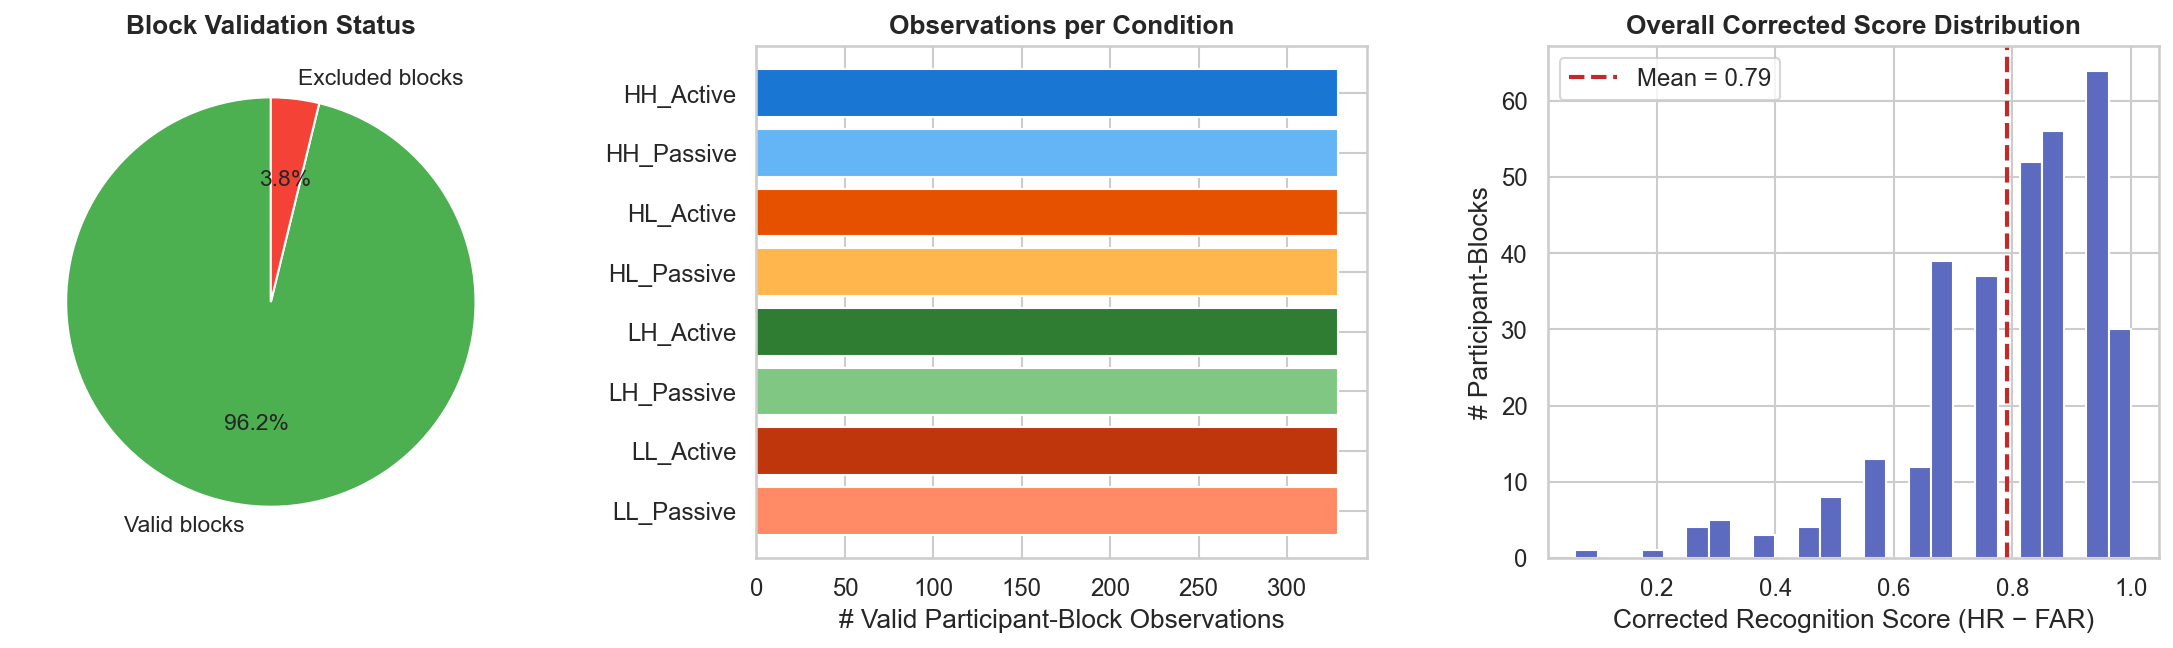

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Block validity pie
labels_pie = ["Valid blocks", "Excluded blocks"]
sizes_pie  = [total_blocks - excluded_blocks, excluded_blocks]
colors_pie = ["#4CAF50", "#F44336"]
axes[0].pie(sizes_pie, labels=labels_pie, autopct="%1.1f%%",
            colors=colors_pie, startangle=90, textprops={"fontsize": 11})
axes[0].set_title("Block Validation Status", fontweight="bold")

# (b) Observations per condition
cond_counts = cond_df.groupby("condition").size().reindex(COND_ORDER)
bar_colors  = [COND_PALETTE[c] for c in COND_ORDER]
axes[1].barh(COND_ORDER, cond_counts.values, color=bar_colors)
axes[1].set_xlabel("# Valid Participant-Block Observations")
axes[1].set_title("Observations per Condition", fontweight="bold")
axes[1].invert_yaxis()

# (c) Corrected score distribution
axes[2].hist(pb_df["corrected"], bins=25, color="#5C6BC0", edgecolor="white")
axes[2].axvline(pb_df["corrected"].mean(), color="#C62828", ls="--", lw=2,
                label=f'Mean = {pb_df["corrected"].mean():.2f}')
axes[2].set_xlabel("Corrected Recognition Score (HR − FAR)")
axes[2].set_ylabel("# Participant-Blocks")
axes[2].set_title("Overall Corrected Score Distribution", fontweight="bold")
axes[2].legend()

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "01_data_overview.png"))
plt.show()

---
## 6. Plot 2 — Mean Corrected Memorability by Sentence Type (Bar Chart)

In [74]:
fig, ax = plt.subplots(figsize=(7, 5))
type_agg = cond_df.groupby("sent_type")["corrected"].agg(["mean", "sem", "count"]).reindex(TYPE_ORDER)

bars = ax.bar(TYPE_ORDER, type_agg["mean"],
              yerr=type_agg["sem"] * 1.96, capsize=5,
              color=[TYPE_PALETTE[t] for t in TYPE_ORDER],
              edgecolor="white", linewidth=1.5, width=0.6)
ax.set_ylabel("Corrected Memorability (HR − FAR)")
ax.set_xlabel("Sentence Type")
ax.set_title("Mean Corrected Memorability by Sentence Type", fontweight="bold", pad=12)
for b, t in zip(bars, TYPE_ORDER):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
            f"{type_agg.loc[t, 'mean']:.3f}", ha="center", fontsize=10)
ax.axhline(0, color="grey", ls="--", lw=0.8)

# Set y-axis limits with padding
data_min = cond_df.groupby("sent_type")["corrected"].mean().min()
data_max = cond_df.groupby("sent_type")["corrected"].mean().max()

data_range = data_max - data_minplt.show()

ax.set_ylim(data_min - 0.25 * data_range, data_max + 0.25 * data_range)fig.savefig(os.path.join(PLOT_DIR, "02_memorability_by_type.png"))

fig.tight_layout()

SyntaxError: invalid syntax (803578783.py, line 22)

---
## 6b. Plot 2b — Recognition Accuracy by Sentence Type (ordered by noun memorability)

Each sentence has two key nouns (subject & object), each rated High or Low memorability.  
**LL** (0 high-mem nouns) → **LH** (high object) → **HL** (high subject) → **HH** (2 high-mem nouns).

> *"Sentences containing highly memorable nouns tend to have higher recognition accuracy."*

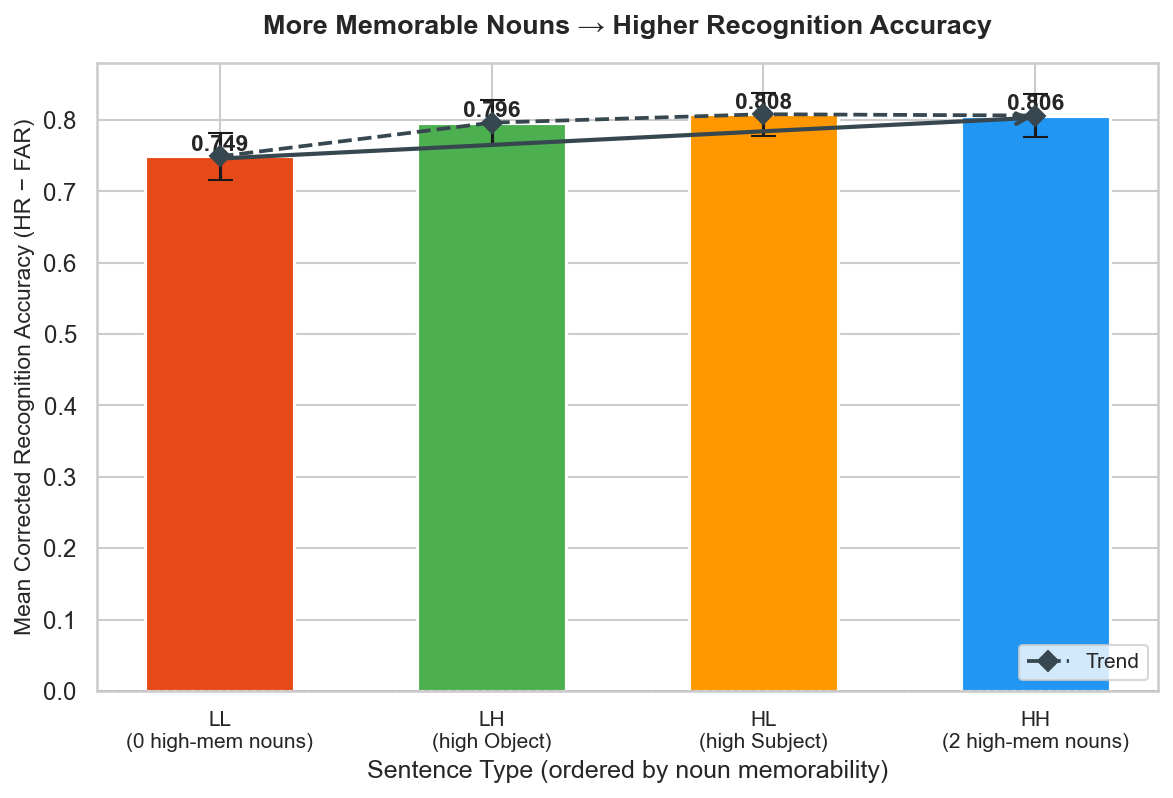


── Summary ──
  LL: mean = 0.7491  (n = 112 participants)
  LH: mean = 0.7963  (n = 112 participants)
  HL: mean = 0.8082  (n = 112 participants)
  HH: mean = 0.8064  (n = 112 participants)


In [ ]:
# ── Aggregate per sentence type (keep HL and LH separate) ──
# Order: LL (0 high-mem) → LH (1: high object) → HL (1: high subject) → HH (2 high-mem)
type_order_mem = ["LL", "LH", "HL", "HH"]
noun_labels = {
    "LL": "LL\n(0 high-mem nouns)",
    "LH": "LH\n(high Object)",
    "HL": "HL\n(high Subject)",
    "HH": "HH\n(2 high-mem nouns)",
}
bar_colors_mem = ["#E64A19", "#4CAF50", "#FF9800", "#2196F3"]

# Participant-level means per sentence type
part_type = (cond_df.groupby(["participant_ID", "sent_type"])["corrected"]
             .mean().reset_index())
type_agg2 = (part_type.groupby("sent_type")["corrected"]
             .agg(["mean", "sem", "count"])
             .reindex(type_order_mem))

# ── Plot ──
fig, ax = plt.subplots(figsize=(8, 5.5))
x_pos = np.arange(len(type_order_mem))

bars = ax.bar(x_pos, type_agg2["mean"], yerr=type_agg2["sem"] * 1.96, capsize=6,
              color=bar_colors_mem, edgecolor="white", linewidth=1.5, width=0.55)

# Value labels
for bar, t in zip(bars, type_order_mem):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f"{type_agg2.loc[t, 'mean']:.3f}", ha="center", fontsize=11, fontweight="bold")

# Trend line connecting bar tops
ax.plot(x_pos, type_agg2["mean"].values, color="#37474F", ls="--", lw=1.8,
        marker="D", markersize=7, zorder=5, label="Trend")

ax.set_xticks(x_pos)
ax.set_xticklabels([noun_labels[t] for t in type_order_mem], fontsize=10)
ax.set_xlabel("Sentence Type (ordered by noun memorability)", fontsize=12)
ax.set_ylabel("Mean Corrected Recognition Accuracy (HR − FAR)", fontsize=11)
ax.set_title("More Memorable Nouns → Higher Recognition Accuracy",
             fontweight="bold", fontsize=13, pad=14)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.legend(loc="lower right", fontsize=10)

# Annotation arrow
ax.annotate("", xy=(3, type_agg2.loc["HH", "mean"] - 0.003),
            xytext=(0, type_agg2.loc["LL", "mean"] - 0.003),
            arrowprops=dict(arrowstyle="->", color="#37474F", lw=2))

# Set y-axis limits with padding
data_min = type_agg2["mean"].min()
data_max = type_agg2["mean"].max()
data_range = data_max - data_min
ax.set_ylim(data_min - 0.25 * data_range, data_max + 0.25 * data_range)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "02b_accuracy_vs_noun_memorability.png"))
plt.show()

          f"(n = {int(type_agg2.loc[t, 'count'])} participants)")

# Print summary    print(f"  {t}: mean = {type_agg2.loc[t, 'mean']:.4f}  "

print("\n── Summary ──")for t in type_order_mem:

---
## 7. Plot 3 — Grouped Bar: Sentence Type × Voice

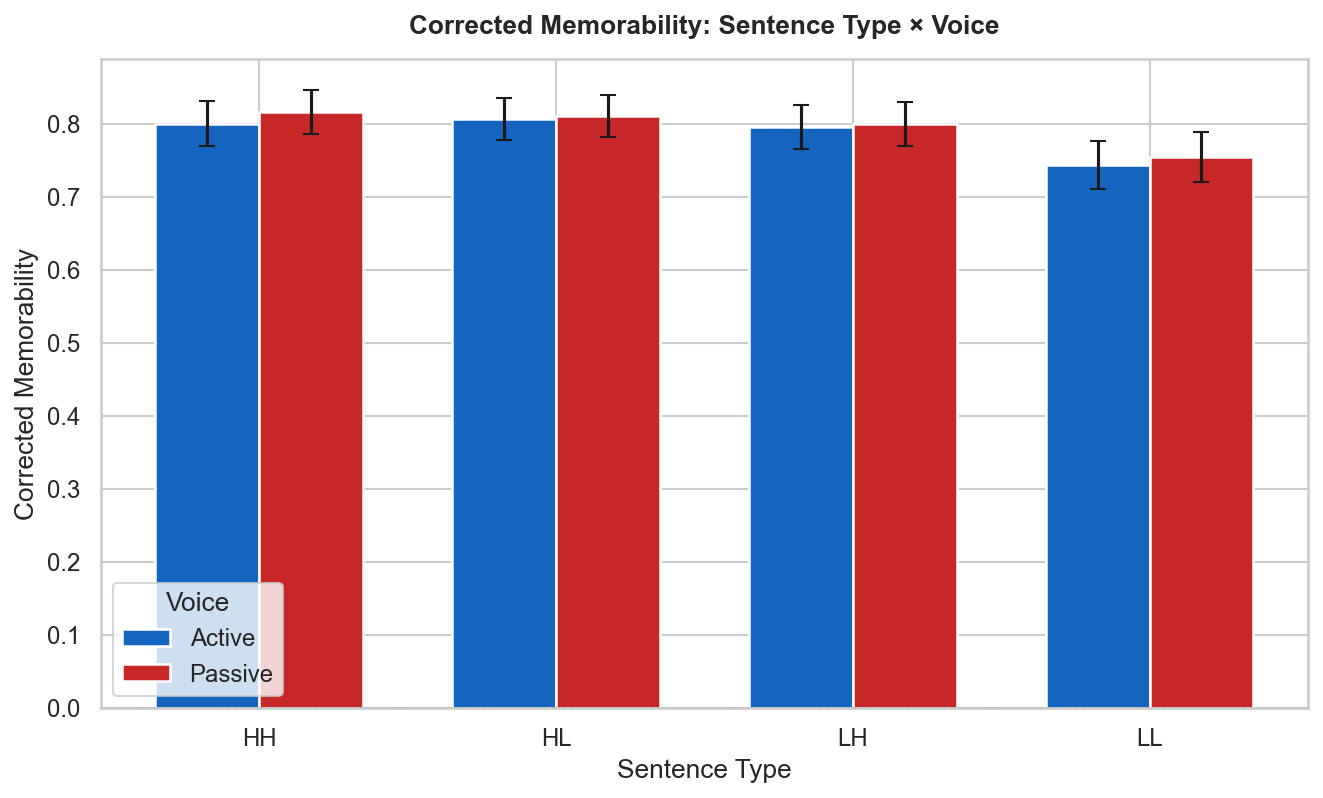

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(TYPE_ORDER))
width = 0.35

for i, v in enumerate(VOICE_ORDER):
    means, cis = [], []
    for t in TYPE_ORDER:
        sub = cond_df[(cond_df["sent_type"] == t) & (cond_df["voice"] == v)]
        m, ci = mean_ci(sub["corrected"])
        means.append(m); cis.append(ci)
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=cis, capsize=4,
           label=v, color=VOICE_PALETTE[v], edgecolor="white", linewidth=1.2)

ax.set_xticks(x); ax.set_xticklabels(TYPE_ORDER)
ax.set_ylabel("Corrected Memorability"); ax.set_xlabel("Sentence Type")
ax.set_title("Corrected Memorability: Sentence Type × Voice", fontweight="bold", pad=12)
ax.legend(title="Voice"); ax.axhline(0, color="grey", ls="--", lw=0.8)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "03_type_x_voice_bar.png"))
plt.show()

---
## 8. Plot 4 — Box Plots: All 8 Conditions

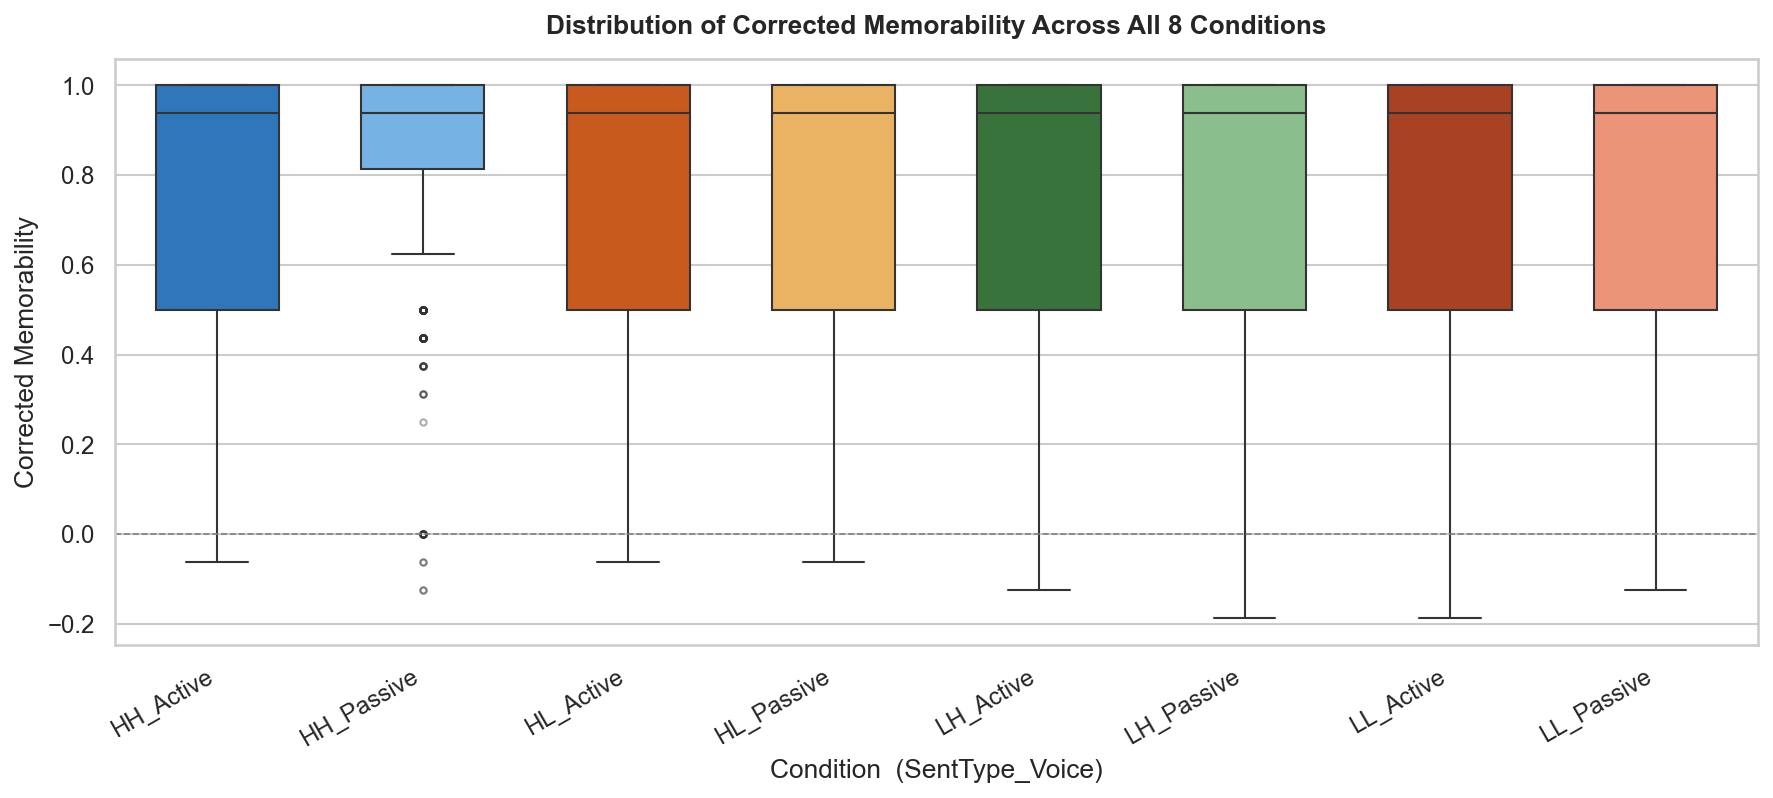

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5.5))
cond_df["condition_f"] = pd.Categorical(cond_df["condition"], categories=COND_ORDER, ordered=True)
palette_list = [COND_PALETTE[c] for c in COND_ORDER]

sns.boxplot(data=cond_df, x="condition_f", y="corrected",
            palette=palette_list, ax=ax, width=0.6,
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
ax.set_xlabel("Condition  (SentType_Voice)")
ax.set_ylabel("Corrected Memorability")
ax.set_title("Distribution of Corrected Memorability Across All 8 Conditions", fontweight="bold", pad=12)
ax.axhline(0, color="grey", ls="--", lw=0.8)
plt.xticks(rotation=30, ha="right")

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "04_boxplots_all_conditions.png"))
plt.show()

---
## 9. Plot 5 — Violin Plots by Sentence Type

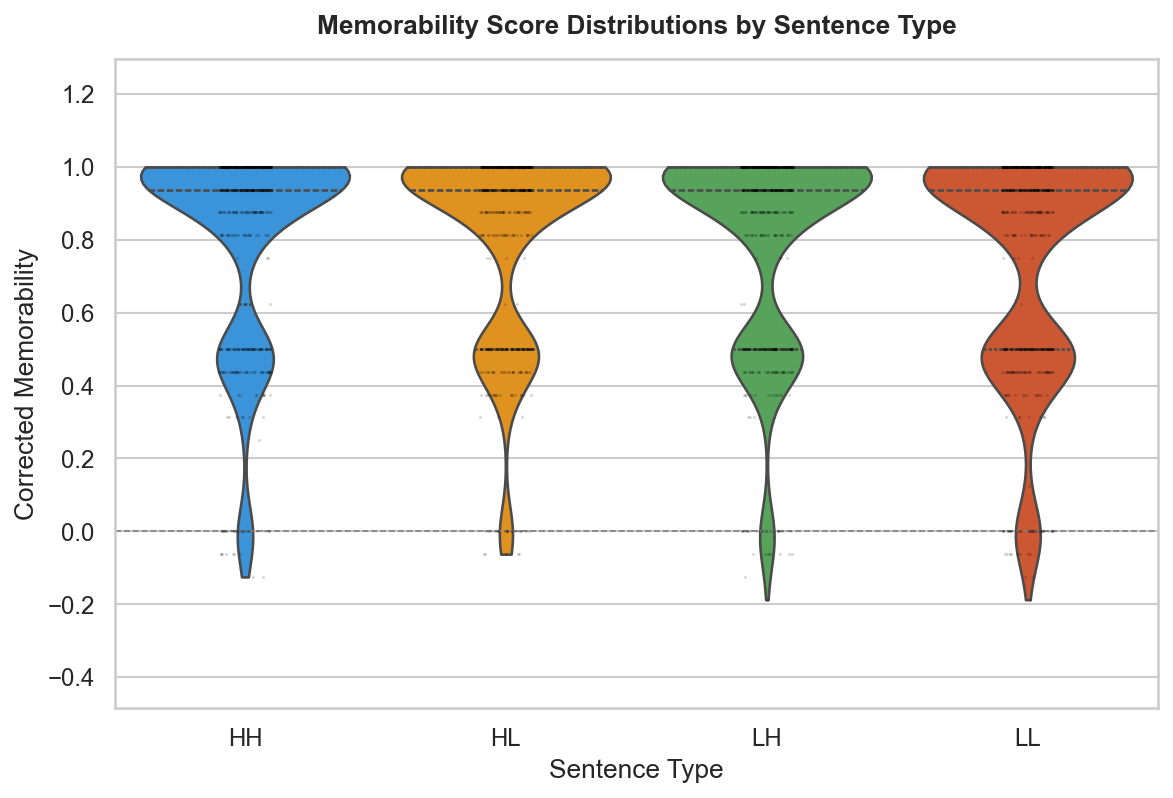

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.violinplot(data=cond_df, x="sent_type", y="corrected",
               order=TYPE_ORDER, palette=TYPE_PALETTE, inner="quartile", ax=ax, cut=0)
sns.stripplot(data=cond_df, x="sent_type", y="corrected",
              order=TYPE_ORDER, color="black", size=1.5, alpha=0.15, jitter=True, ax=ax)
ax.set_xlabel("Sentence Type"); ax.set_ylabel("Corrected Memorability")
ax.set_title("Memorability Score Distributions by Sentence Type", fontweight="bold", pad=12)
ax.axhline(0, color="grey", ls="--", lw=0.8)

# Set y-axis limits to accommodate full violin shape
data_min = cond_df["corrected"].min()
data_max = cond_df["corrected"].max()
data_range = data_max - data_min
ax.set_ylim(data_min - 0.25 * data_range, data_max + 0.25 * data_range)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "05_violin_by_type.png"))
plt.show()

---
## 10. Plot 6 — Heatmap: Mean Corrected Memorability (Type × Voice)

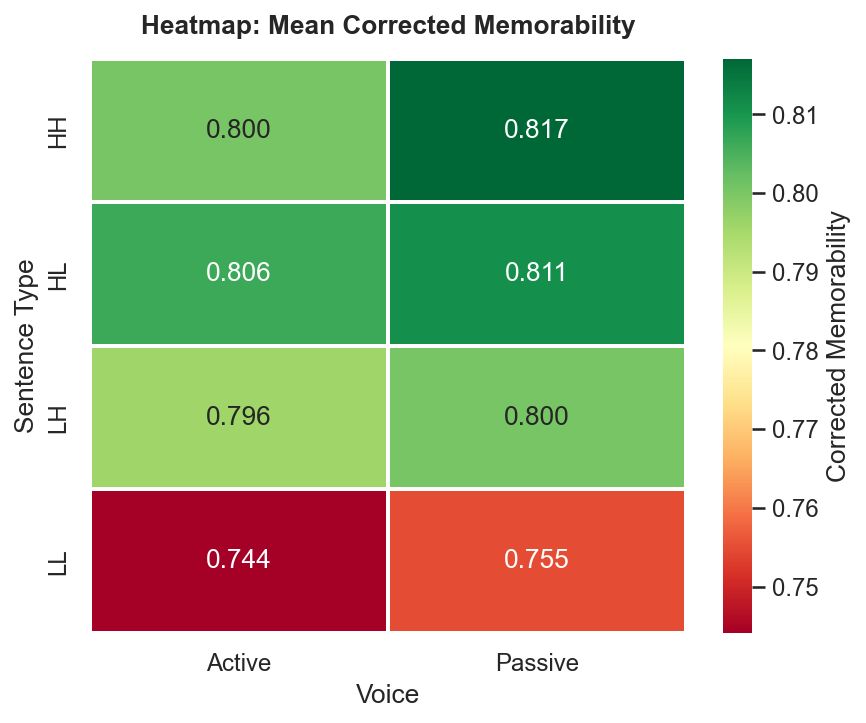

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
heat_data = (cond_df.groupby(["sent_type", "voice"])["corrected"]
             .mean().unstack("voice")
             .reindex(index=TYPE_ORDER, columns=VOICE_ORDER))

sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="RdYlGn",
            linewidths=1, ax=ax, cbar_kws={"label": "Corrected Memorability"})
ax.set_title("Heatmap: Mean Corrected Memorability", fontweight="bold", pad=12)
ax.set_ylabel("Sentence Type"); ax.set_xlabel("Voice")

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "06_heatmap_type_voice.png"))
plt.show()

---
## 11. Plot 7 — Subject × Object Memorability Interaction Plot

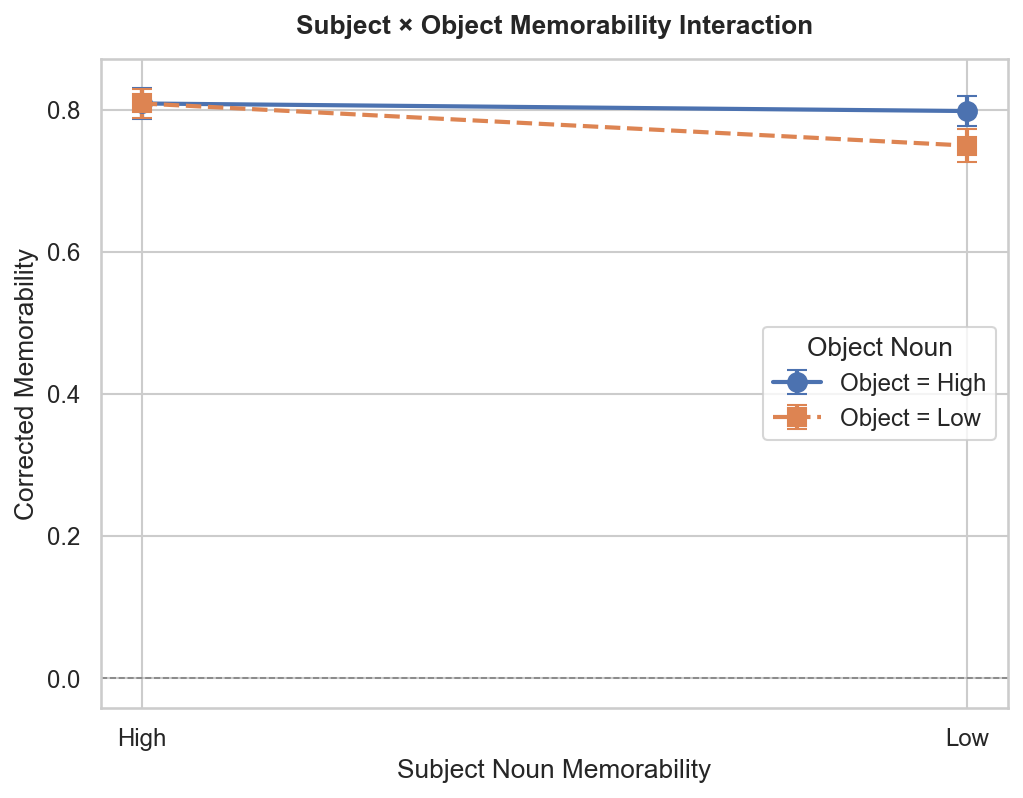

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))

int_data = (cond_df.groupby(["subject_mem", "object_mem"])["corrected"]
            .agg(["mean", "sem"]).reset_index())

for obj_level, marker, ls in [("High", "o", "-"), ("Low", "s", "--")]:
    sub = int_data[int_data["object_mem"] == obj_level].sort_values("subject_mem")
    ax.errorbar(sub["subject_mem"], sub["mean"], yerr=sub["sem"] * 1.96,
                marker=marker, ls=ls, lw=2, markersize=9, capsize=5,
                label=f"Object = {obj_level}")

ax.set_xlabel("Subject Noun Memorability"); ax.set_ylabel("Corrected Memorability")
ax.set_title("Subject × Object Memorability Interaction", fontweight="bold", pad=12)
ax.legend(title="Object Noun"); ax.axhline(0, color="grey", ls="--", lw=0.8)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "07_interaction_subj_obj.png"))
plt.show()

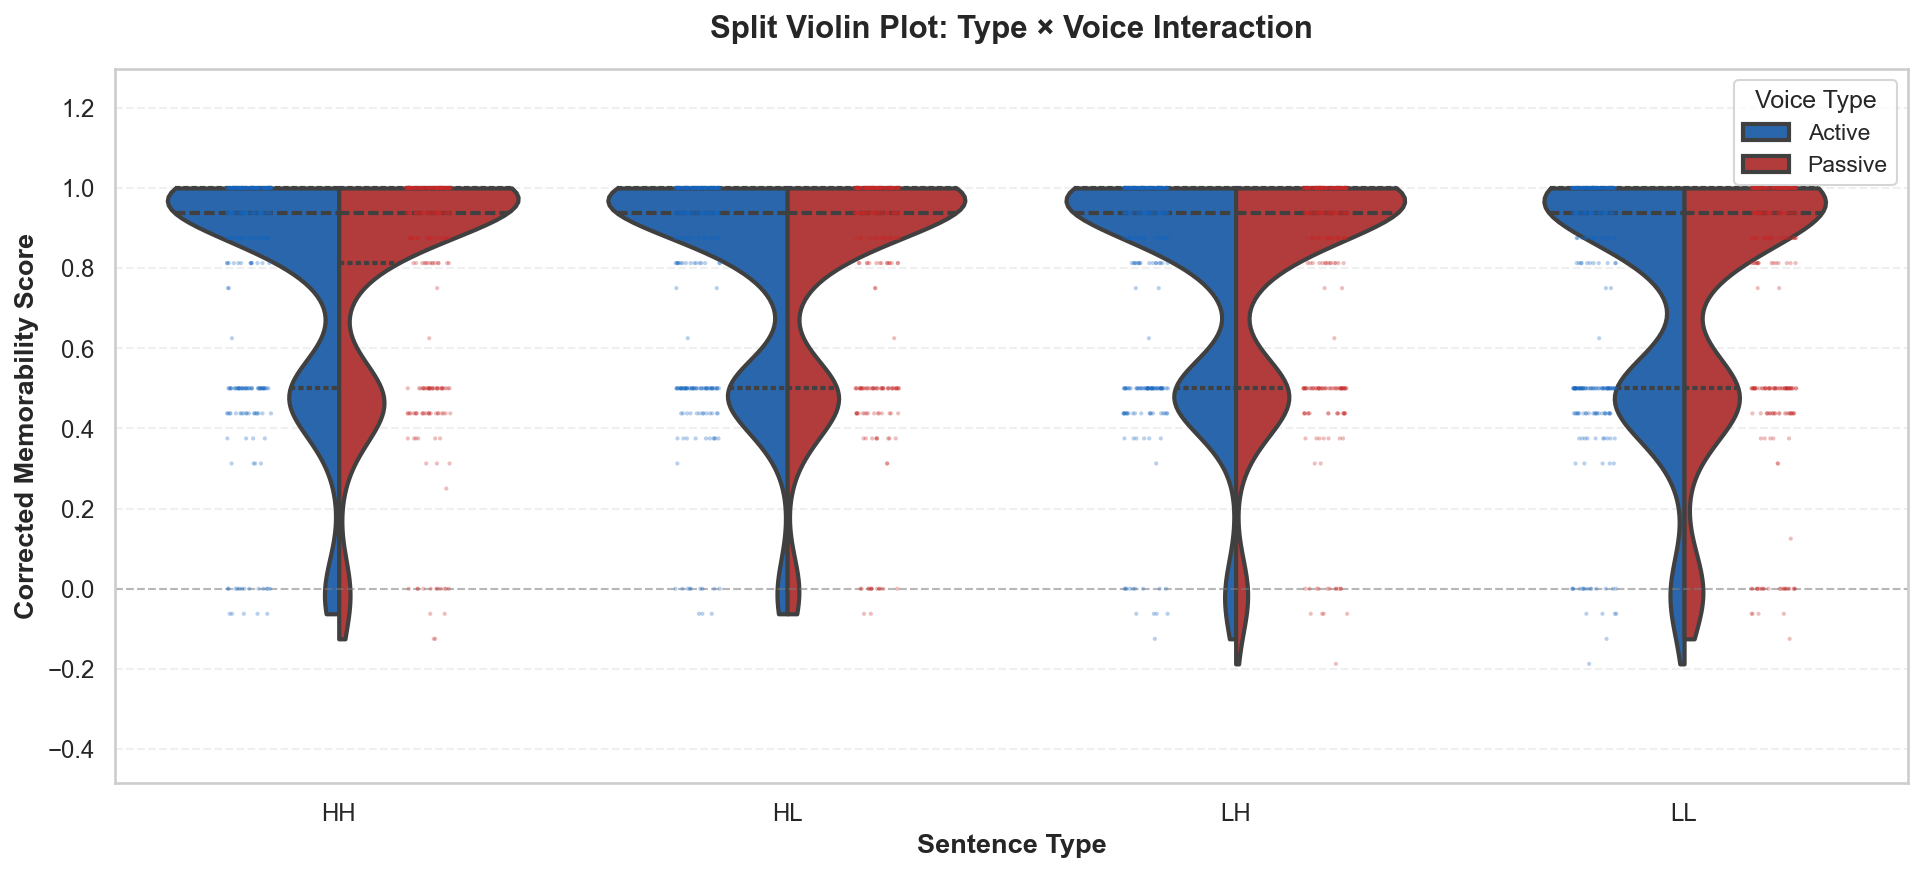


  TYPE × VOICE INTERACTION SUMMARY

HH:
  Active  : μ=0.8003, σ=0.2848, n=329
  Passive : μ=0.8171, σ=0.2772, n=329

HL:
  Active  : μ=0.8064, σ=0.2649, n=329
  Passive : μ=0.8110, σ=0.2703, n=329

LH:
  Active  : μ=0.7958, σ=0.2744, n=329
  Passive : μ=0.8003, σ=0.2801, n=329

LL:
  Active  : μ=0.7441, σ=0.3036, n=329
  Passive : μ=0.7547, σ=0.3123, n=329

✅ All enhanced box & violin plots saved to 'plots/'


In [ ]:
# ── Split Violin Plot: Type × Voice Interaction ──
fig, ax = plt.subplots(figsize=(13, 6))

# Create split violin plot showing both Active and Passive for each type
sns.violinplot(data=cond_df, x="sent_type", y="corrected", hue="voice",
               order=TYPE_ORDER, hue_order=VOICE_ORDER,
               palette=VOICE_PALETTE, split=True, inner="quartile",
               ax=ax, cut=0, linewidth=2)

# Add strip plot overlay
sns.stripplot(data=cond_df, x="sent_type", y="corrected", hue="voice",
              order=TYPE_ORDER, hue_order=VOICE_ORDER,
              palette=VOICE_PALETTE, dodge=True, alpha=0.3, size=2,
              ax=ax, legend=False)

ax.set_xlabel("Sentence Type", fontsize=13, fontweight='bold')
ax.set_ylabel("Corrected Memorability Score", fontsize=13, fontweight='bold')
ax.set_title("Split Violin Plot: Type × Voice Interaction", 
             fontweight="bold", fontsize=15, pad=15)
ax.axhline(0, color="grey", ls="--", lw=1, alpha=0.5)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(title='Voice Type', fontsize=11, title_fontsize=12, loc='upper right')

# Set y-axis limits to accommodate full violin shape
data_min = cond_df["corrected"].min()
data_max = cond_df["corrected"].max()
data_range = data_max - data_min
ax.set_ylim(data_min - 0.25 * data_range, data_max + 0.25 * data_range)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "11d_split_violin_type_voice.png"))
plt.show()

# Print interaction summary
print("\n" + "=" * 70)
print("  TYPE × VOICE INTERACTION SUMMARY")
print("=" * 70)
for stype in TYPE_ORDER:
    print(f"\n{stype}:")
    for voice in VOICE_ORDER:
        voice_type_data = cond_df[(cond_df["sent_type"] == stype) & 
                                   (cond_df["voice"] == voice)]["corrected"]
        print(f"  {voice:8s}: μ={voice_type_data.mean():.4f}, "
              f"σ={voice_type_data.std():.4f}, n={len(voice_type_data)}")
print("=" * 70)

print(f"\n✅ All enhanced box & violin plots saved to '{PLOT_DIR}/'")

---
## 11d. Split Violin Plots — Type × Voice Interaction Visualization

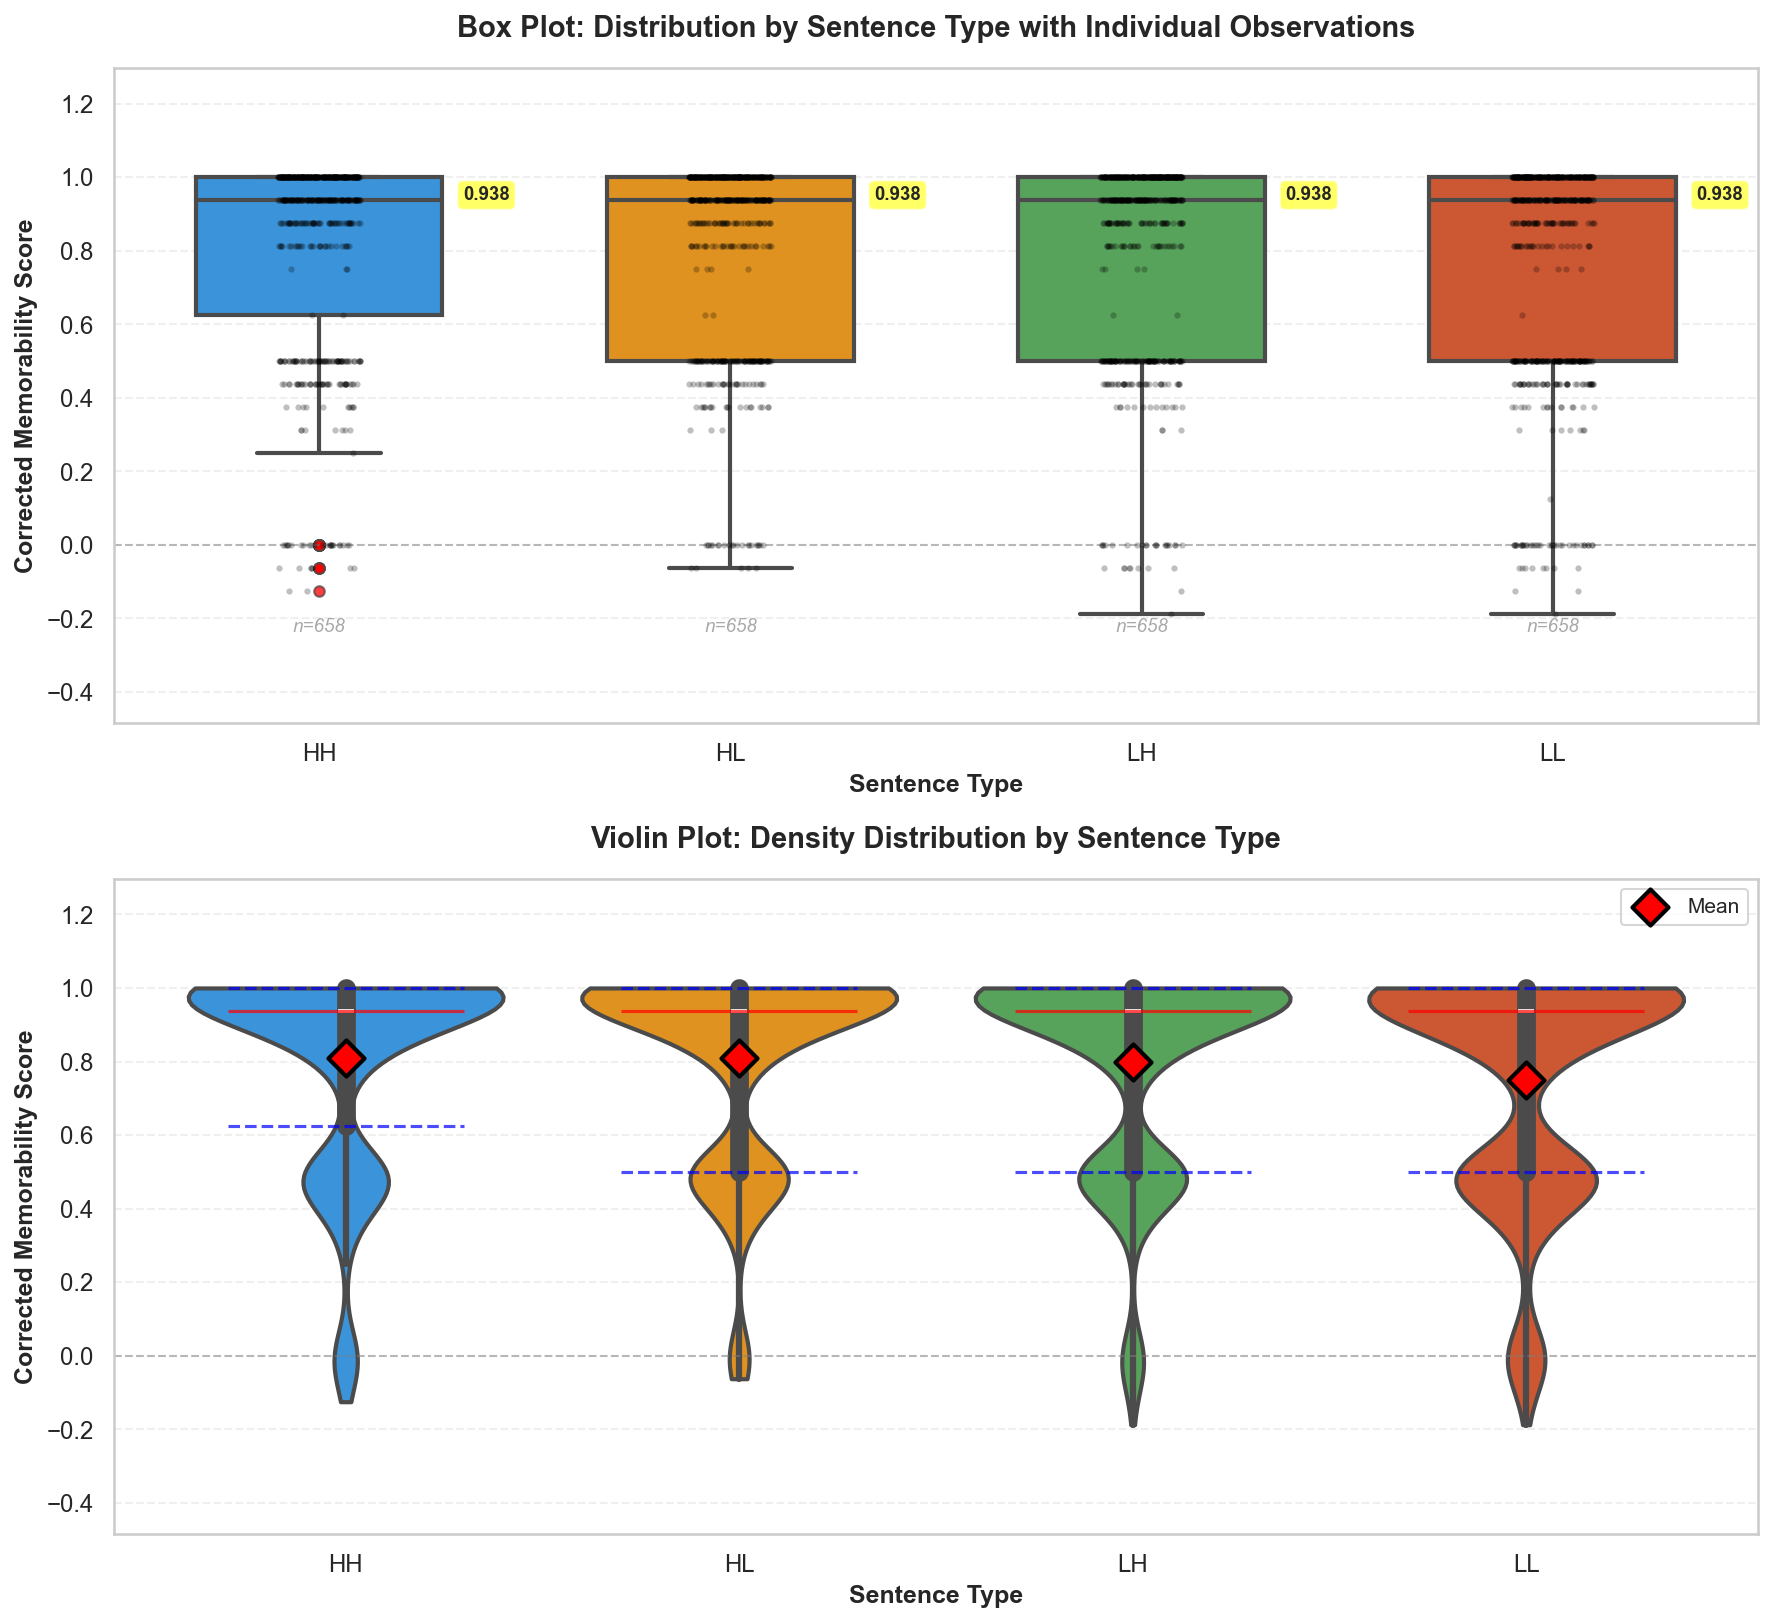


  DETAILED STATISTICS BY SENTENCE TYPE

HH:
  Count    : 658
  Mean     : 0.8087
  Median   : 0.9375
  Std Dev  : 0.2810
  Q1       : 0.6250
  Q3       : 1.0000
  IQR      : 0.3750
  Min      : -0.1250
  Max      : 1.0000

HL:
  Count    : 658
  Mean     : 0.8087
  Median   : 0.9375
  Std Dev  : 0.2674
  Q1       : 0.5000
  Q3       : 1.0000
  IQR      : 0.5000
  Min      : -0.0625
  Max      : 1.0000

LH:
  Count    : 658
  Mean     : 0.7981
  Median   : 0.9375
  Std Dev  : 0.2770
  Q1       : 0.5000
  Q3       : 1.0000
  IQR      : 0.5000
  Min      : -0.1875
  Max      : 1.0000

LL:
  Count    : 658
  Mean     : 0.7494
  Median   : 0.9375
  Std Dev  : 0.3078
  Q1       : 0.5000
  Q3       : 1.0000
  IQR      : 0.5000
  Min      : -0.1875
  Max      : 1.0000


In [ ]:
# ── Enhanced Combined Box & Violin Plot by Sentence Type ──
fig, axes = plt.subplots(2, 1, figsize=(12, 11))

# Top: Enhanced Box Plot
type_palette = [TYPE_PALETTE[t] for t in TYPE_ORDER]
bp = sns.boxplot(data=cond_df, x="sent_type", y="corrected",
                 order=TYPE_ORDER, palette=type_palette,
                 ax=axes[0], width=0.6, linewidth=2,
                 flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))

# Add individual points with jitter
sns.stripplot(data=cond_df, x="sent_type", y="corrected",
              order=TYPE_ORDER, color="black",
              size=3, alpha=0.25, jitter=True, ax=axes[0])

axes[0].set_xlabel("Sentence Type", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Corrected Memorability Score", fontsize=12, fontweight='bold')
axes[0].set_title("Box Plot: Distribution by Sentence Type with Individual Observations", 
                  fontweight="bold", fontsize=14, pad=15)
axes[0].axhline(0, color="grey", ls="--", lw=1, alpha=0.5)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add sample sizes and statistics
for i, stype in enumerate(TYPE_ORDER):
    type_data = cond_df[cond_df["sent_type"] == stype]["corrected"]
    n = len(type_data)
    median = type_data.median()
    q1 = type_data.quantile(0.25)
    q3 = type_data.quantile(0.75)
    
    # Add n label at bottom
    axes[0].text(i, axes[0].get_ylim()[0] + 0.01, f'n={n}',
                ha='center', fontsize=9, style='italic', color='darkgray')
    
    # Add median label
    axes[0].text(i + 0.35, median, f'{median:.3f}',
                ha='left', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.6))

# Bottom: Enhanced Violin Plot
vp = sns.violinplot(data=cond_df, x="sent_type", y="corrected",
                    order=TYPE_ORDER, palette=type_palette,
                    inner="box", ax=axes[1], cut=0, linewidth=2, scale="width")

# Add quartile lines
for i, stype in enumerate(TYPE_ORDER):
    type_data = cond_df[cond_df["sent_type"] == stype]["corrected"]
    q1 = type_data.quantile(0.25)
    q2 = type_data.quantile(0.50)
    q3 = type_data.quantile(0.75)
    
    # Add horizontal lines for quartiles
    axes[1].hlines([q1, q2, q3], i-0.3, i+0.3, colors=['blue', 'red', 'blue'], 
                   linestyles=['--', '-', '--'], linewidth=1.5, alpha=0.7)

axes[1].set_xlabel("Sentence Type", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Corrected Memorability Score", fontsize=12, fontweight='bold')
axes[1].set_title("Violin Plot: Density Distribution by Sentence Type", 
                  fontweight="bold", fontsize=14, pad=15)
axes[1].axhline(0, color="grey", ls="--", lw=1, alpha=0.5)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Set y-axis limits for both subplots to accommodate full shapes
data_min = cond_df["corrected"].min()
data_max = cond_df["corrected"].max()
data_range = data_max - data_min
for ax in axes:
    ax.set_ylim(data_min - 0.25 * data_range, data_max + 0.25 * data_range)

# Add mean markers
for i, stype in enumerate(TYPE_ORDER):
    type_data = cond_df[cond_df["sent_type"] == stype]["corrected"]
    mean = type_data.mean()
    axes[1].scatter(i, mean, color='red', s=150, marker='D', 
                    edgecolors='black', linewidths=2, zorder=10, label='Mean' if i == 0 else '')

axes[1].legend(loc='upper right', fontsize=10)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "11c_enhanced_box_violin_by_type.png"))
plt.show()

# Print detailed statistics
print("\n" + "=" * 70)
print("  DETAILED STATISTICS BY SENTENCE TYPE")
print("=" * 70)
for stype in TYPE_ORDER:
    type_data = cond_df[cond_df["sent_type"] == stype]["corrected"]
    print(f"\n{stype}:")
    print(f"  Count    : {len(type_data)}")
    print(f"  Mean     : {type_data.mean():.4f}")
    print(f"  Median   : {type_data.median():.4f}")
    print(f"  Std Dev  : {type_data.std():.4f}")
    print(f"  Q1       : {type_data.quantile(0.25):.4f}")
    print(f"  Q3       : {type_data.quantile(0.75):.4f}")
    print(f"  IQR      : {type_data.quantile(0.75) - type_data.quantile(0.25):.4f}")
    print(f"  Min      : {type_data.min():.4f}")
    print(f"  Max      : {type_data.max():.4f}")
print("=" * 70)

---
## 11c. Enhanced Box & Violin Plots — Sentence Type with Statistical Annotations

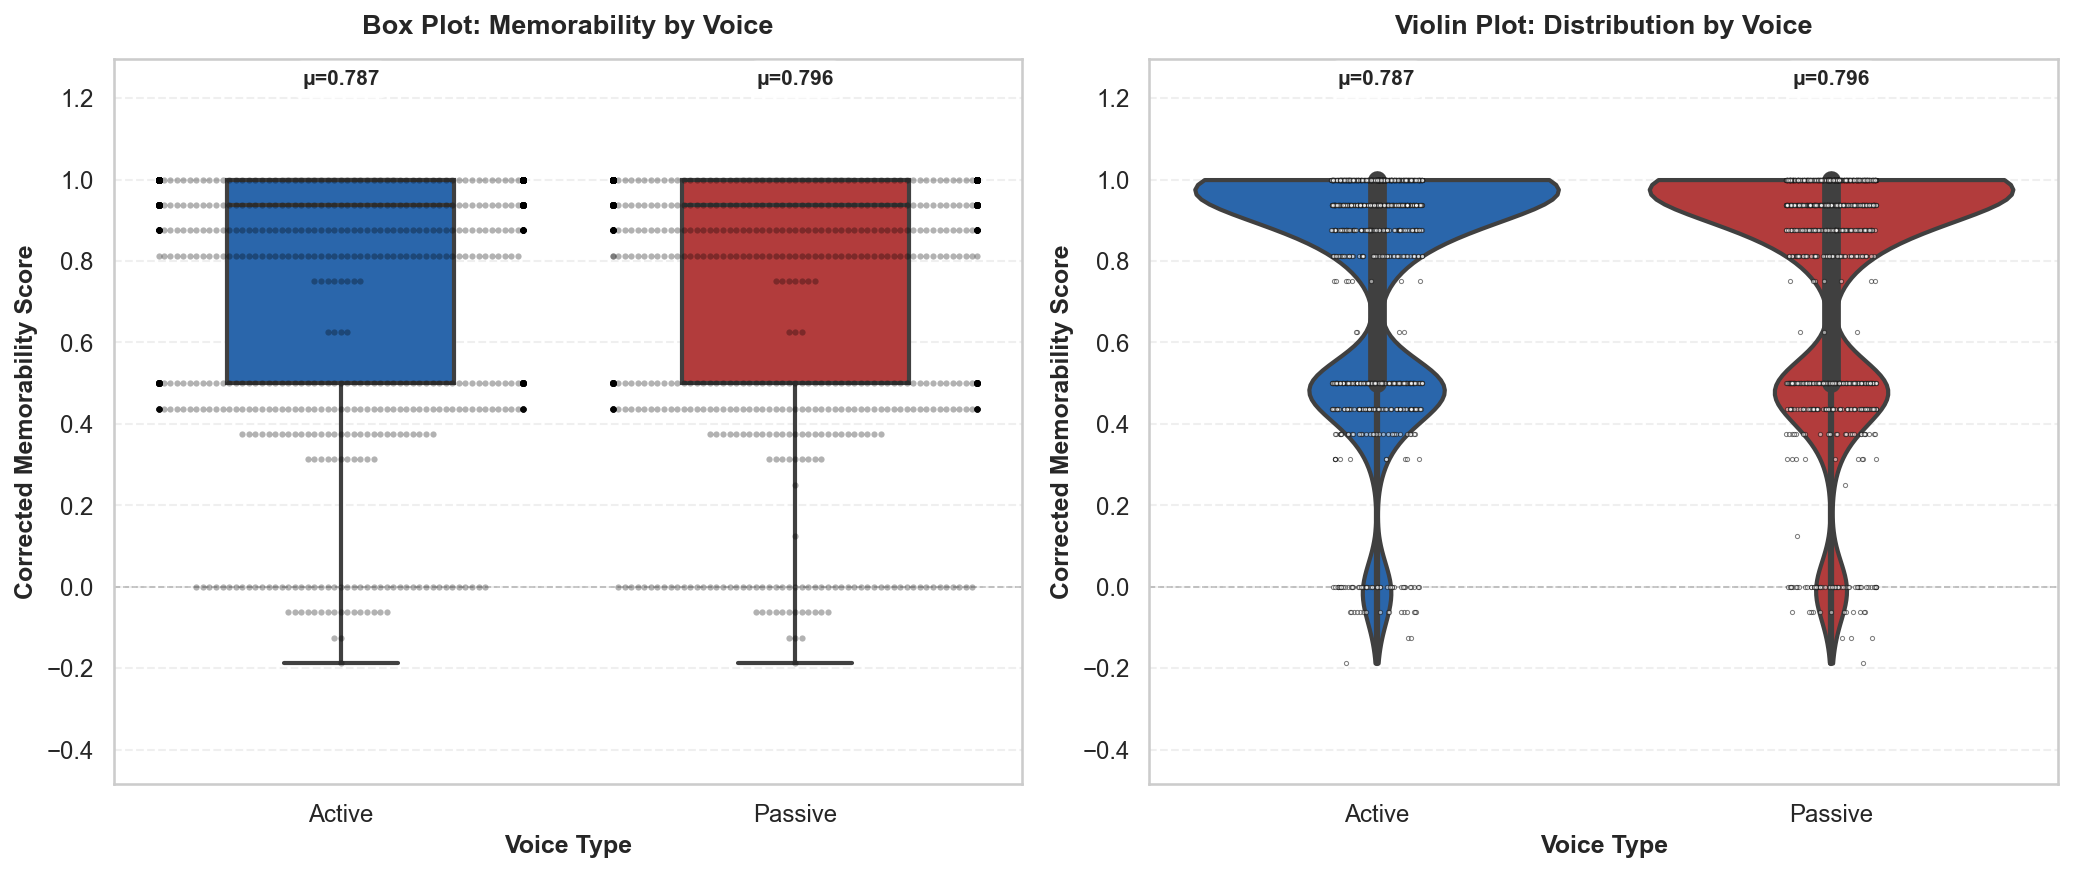


✅ Combined box & violin plots saved to 'plots/'


In [ ]:
# ── Enhanced Combined Box & Violin Plot by Voice ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Box plot by voice
box_palette = [VOICE_PALETTE[v] for v in VOICE_ORDER]
sns.boxplot(data=cond_df, x="voice", y="corrected", 
            order=VOICE_ORDER, palette=box_palette, 
            ax=axes[0], width=0.5, linewidth=2)
sns.swarmplot(data=cond_df, x="voice", y="corrected",
              order=VOICE_ORDER, color="black", 
              size=3, alpha=0.3, ax=axes[0])

axes[0].set_xlabel("Voice Type", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Corrected Memorability Score", fontsize=12, fontweight='bold')
axes[0].set_title("Box Plot: Memorability by Voice", fontweight="bold", fontsize=13, pad=12)
axes[0].axhline(0, color="grey", ls="--", lw=0.8, alpha=0.5)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Right: Violin plot by voice
sns.violinplot(data=cond_df, x="voice", y="corrected",
               order=VOICE_ORDER, palette=box_palette,
               inner="box", ax=axes[1], cut=0, linewidth=2)
sns.stripplot(data=cond_df, x="voice", y="corrected",
              order=VOICE_ORDER, color="white",
              size=2, alpha=0.5, jitter=True, ax=axes[1], edgecolor='black', linewidth=0.5)

axes[1].set_xlabel("Voice Type", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Corrected Memorability Score", fontsize=12, fontweight='bold')
axes[1].set_title("Violin Plot: Distribution by Voice", fontweight="bold", fontsize=13, pad=12)
axes[1].axhline(0, color="grey", ls="--", lw=0.8, alpha=0.5)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Set y-axis limits for both subplots to accommodate full shapes
data_min = cond_df["corrected"].min()
data_max = cond_df["corrected"].max()
data_range = data_max - data_min
for ax in axes:
    ax.set_ylim(data_min - 0.25 * data_range, data_max + 0.25 * data_range)

# Add statistical annotations
for ax in axes:
    # Calculate means and add them
    for i, voice in enumerate(VOICE_ORDER):
        voice_data = cond_df[cond_df["voice"] == voice]["corrected"]
        mean_val = voice_data.mean()
        ax.text(i, ax.get_ylim()[1] * 0.95, f'μ={mean_val:.3f}',
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "11b_box_violin_by_voice.png"))
plt.show()

print(f"\n✅ Combined box & violin plots saved to '{PLOT_DIR}/'")

---
## 11b. Enhanced Box & Violin Plots — Combined View by Voice Type

---
## Descriptive Statistics Table — Recognition Accuracy by Sentence Type

In [ ]:
# ── Descriptive statistics: recognition accuracy (corrected) by sentence type ──
desc_table = (cond_df.groupby("sent_type")["corrected"]
              .agg(["mean", "std"])
              .reindex(TYPE_ORDER)
              .rename(columns={"mean": "Mean Accuracy", "std": "Std Dev"}))

desc_table.index.name = "Sentence Type"

# Display as a clean table
print("Descriptive statistics for recognition accuracy across sentence types\n")
print(desc_table.to_string(float_format=lambda x: f"{x:.4f}"))

# ── Also produce the LaTeX you can paste directly into your paper ──
latex_rows = []
for t in TYPE_ORDER:
    m = desc_table.loc[t, "Mean Accuracy"]
    s = desc_table.loc[t, "Std Dev"]
    latex_rows.append(f"    {t} & {m:.4f} & {s:.4f} \\\\")

latex_table = r"""\begin{table}[h]
\centering
\begin{tabular}{ccc}
\toprule
Sentence Type & Mean Accuracy & Std Dev \\
\midrule
""" + "\n".join(latex_rows) + r"""
\bottomrule
\end{tabular}
\caption{Descriptive statistics for recognition accuracy across sentence types}
\label{tab:desc}
\end{table}"""

print("\n\n── LaTeX (copy-paste ready) ──\n")
print(latex_table)

Descriptive statistics for recognition accuracy across sentence types

               Mean Accuracy  Std Dev
Sentence Type                        
HH                    0.8087   0.2810
HL                    0.8087   0.2674
LH                    0.7981   0.2770
LL                    0.7494   0.3078


── LaTeX (copy-paste ready) ──

\begin{table}[h]
\centering
\begin{tabular}{ccc}
\toprule
Sentence Type & Mean Accuracy & Std Dev \\
\midrule
    HH & 0.8087 & 0.2810 \\
    HL & 0.8087 & 0.2674 \\
    LH & 0.7981 & 0.2770 \\
    LL & 0.7494 & 0.3078 \\
\bottomrule
\end{tabular}
\caption{Descriptive statistics for recognition accuracy across sentence types}
\label{tab:desc}
\end{table}


---
## Recognition Accuracy (%) by Voice Type — Active vs Passive

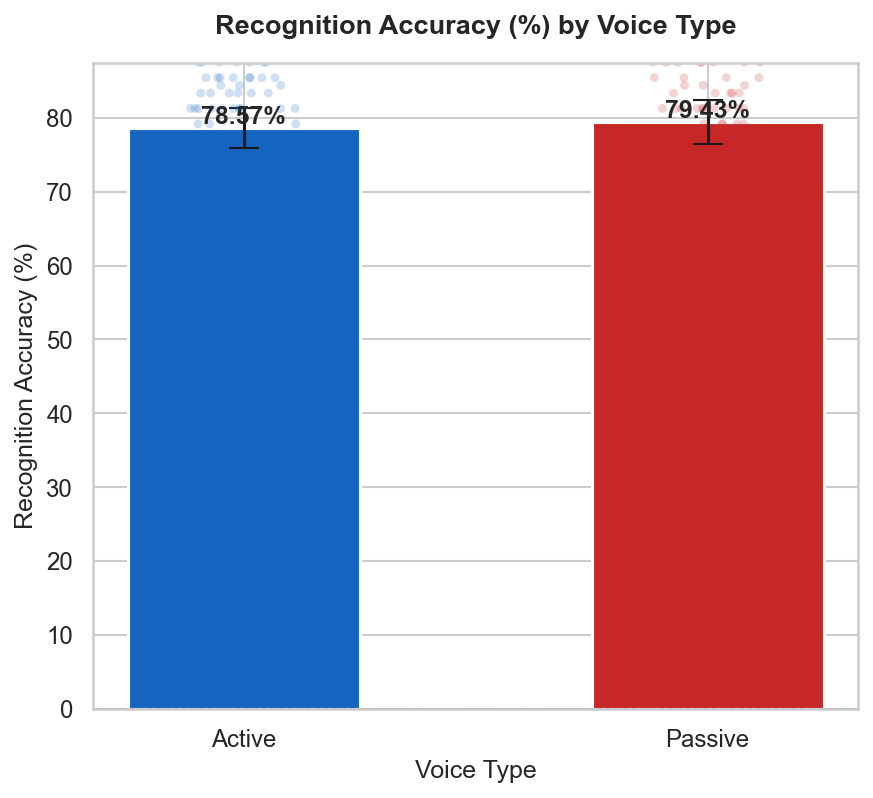


── Summary ──
  Active  : 78.57%  (±2.71% 95% CI, n = 112 participants)
  Passive : 79.43%  (±2.94% 95% CI, n = 112 participants)

  Difference (Active − Passive): -0.86 pp


In [ ]:
# ── Recognition Accuracy (%) by Voice Type ──
# Participant-level: average corrected score per voice, then aggregate
part_voice = (cond_df.groupby(["participant_ID", "voice"])["corrected"]
              .mean().reset_index())
voice_agg = part_voice.groupby("voice")["corrected"].agg(["mean", "sem", "count"]).reindex(VOICE_ORDER)

# Convert to percentage
voice_agg["mean_pct"] = voice_agg["mean"] * 100
voice_agg["sem_pct"]  = voice_agg["sem"] * 100

fig, ax = plt.subplots(figsize=(6, 5.5))

bars = ax.bar(VOICE_ORDER, voice_agg["mean_pct"],
              yerr=voice_agg["sem_pct"] * 1.96, capsize=7,
              color=[VOICE_PALETTE[v] for v in VOICE_ORDER],
              edgecolor="white", linewidth=1.5, width=0.5)

# Value labels on bars
for bar, v in zip(bars, VOICE_ORDER):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6,
            f"{voice_agg.loc[v, 'mean_pct']:.2f}%",
            ha="center", fontsize=12, fontweight="bold")

ax.set_ylabel("Recognition Accuracy (%)", fontsize=12)
ax.set_xlabel("Voice Type", fontsize=12)
ax.set_title("Recognition Accuracy (%) by Voice Type", fontweight="bold", fontsize=13, pad=14)
ax.set_ylim(0, max(voice_agg["mean_pct"]) + 8)
ax.axhline(0, color="grey", ls="--", lw=0.8)

# Individual participant dots (jittered)
for i, v in enumerate(VOICE_ORDER):
    sub = part_voice[part_voice["voice"] == v]["corrected"] * 100
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, size=len(sub))
    ax.scatter(np.full(len(sub), i) + jitter, sub, color=VOICE_PALETTE[v],
               alpha=0.2, s=18, zorder=2, edgecolors="none")

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "08_accuracy_by_voice.png"))
plt.show()

# Print summary
diff = voice_agg.loc["Active", "mean_pct"] - voice_agg.loc["Passive", "mean_pct"]
print(f"\n── Summary ──")
for v in VOICE_ORDER:
    print(f"  {v:8s}: {voice_agg.loc[v, 'mean_pct']:.2f}%  "
          f"(±{voice_agg.loc[v, 'sem_pct'] * 1.96:.2f}% 95% CI, "
          f"n = {int(voice_agg.loc[v, 'count'])} participants)")
print(f"\n  Difference (Active − Passive): {diff:+.2f} pp")